In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set plotting style
# plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
from qcat.parser.qm_reader import load_xarray_h5, repetition_data
from qcat.utilities.simple_visualization import plot_2d_colormap_from_h5

In [39]:
# Define the path to the h5 file
h5_file_path = r"d:\github\ASQMDriver\data\2Q1C_17\2026-02-08\#1432_LCH_qubit_parametric_drive_fixed_time_163947\ds_raw.h5"

# Check if file exists
if os.path.exists(h5_file_path):
    print(f"Found h5 file: {h5_file_path}")
else:
    print(f"File not found: {h5_file_path}")
    print(f"Current directory: {os.getcwd()}")
    print("Available files in current directory:")
    for file in os.listdir('.'):
        if file.endswith('.h5'):
            print(f"  - {file}")
# Load data using the qcat parser
try:
    ds = load_xarray_h5(h5_file_path)
    print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")
    print(f"Coordinates: {list(ds.coords.keys())}")
    print(f"Data variables: {list(ds.data_vars.keys())}")
    
    # Check if it has multiple qubits/repetitions
    if 'qubit' in ds.dims:
        print(f"\nFound {ds.sizes['qubit']} qubits in the dataset")
        qubit_data = repetition_data(ds, repetition_dim="qubit")
        print(f"Separated data into {len(qubit_data)} individual qubit datasets")
    else:
        qubit_data = [ds]  # Single dataset
        print("Single dataset (no qubit dimension)")
        
except Exception as e:
    print(f"Error loading file: {e}")
    ds = None

Found h5 file: d:\github\ASQMDriver\data\2Q1C_17\2026-02-08\#1432_LCH_qubit_parametric_drive_fixed_time_163947\ds_raw.h5
Successfully loaded dataset with dimensions: {'driving_frequency': 201, 'amplitude_ratio': 3, 'qubit': 1}
Coordinates: ['driving_frequency', 'amplitude_ratio', 'qubit']
Data variables: ['state']

Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets


C:\Users\shiau\AppData\Local\Temp\ipykernel_33940\4225996842.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")


Creating heatmaps...

Processing qubit 0: q1
Available data variables: ['state']
Available coordinates: ['driving_frequency', 'amplitude_ratio']
Plotting: state vs amplitude_ratio, driving_frequency


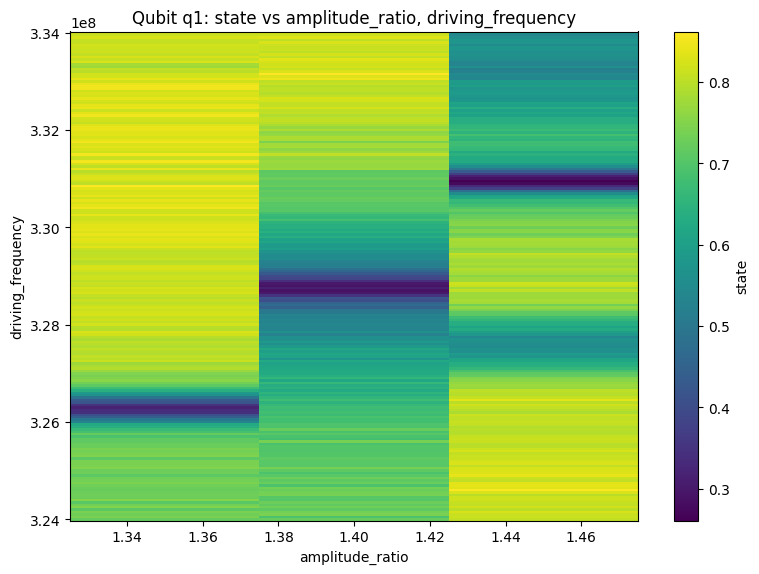


Heatmap creation complete!


In [40]:
# Analyze dataset structure and create heatmaps
if ds is not None and 'qubit_data' in locals():
    print("Creating heatmaps...")
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
            
        # Get available data variables and coordinates
        data_vars = list(sq_data.data_vars.keys())
        coords = [c for c in sq_data.coords.keys() if c != 'qubit']  # Exclude qubit coordinate
        
        print(f"Available data variables: {data_vars}")
        print(f"Available coordinates: {coords}")
        
        # User-specified plotting parameters
        x_dim = "amplitude_ratio"
        y_dim = "driving_frequency"
        data_var = "state"  # Specify your data variable here
        
        print(f"Plotting: {data_var} vs {x_dim}, {y_dim}")
        fig = plot_2d_colormap_from_h5(sq_data, data_var, x_dim, y_dim)
        if fig:
            plt.show()
    
    print("\nHeatmap creation complete!")

In [41]:
# Find driving frequency with minimum state value for each amplitude ratio (with smoothing)
from scipy import ndimage
from scipy.signal import savgol_filter

def find_min_driving_points(sq_data, smooth_method='savgol', smooth_params=None):
    """
    Find the driving frequency that gives minimum state value for each amplitude ratio.
    Applies smoothing along frequency axis before finding minimum.
    
    Args:
        sq_data: xarray dataset containing 'state', 'amplitude_ratio', and 'driving_frequency'
        smooth_method: 'savgol', 'gaussian', or 'none'
        smooth_params: dict with parameters for smoothing method
    
    Returns:
        tuple: (min_points, smoothed_data_2d)
            min_points: List of tuples [(amplitude_ratio, driving_frequency), ...]
            smoothed_data_2d: 2D numpy array of smoothed state data
    """
    if 'state' not in sq_data.data_vars:
        print("Error: 'state' variable not found in dataset")
        return [], None
    
    if 'amplitude_ratio' not in sq_data.dims or 'driving_frequency' not in sq_data.dims:
        print("Error: Required dimensions 'amplitude_ratio' or 'driving_frequency' not found")
        return [], None
    
    # Default smoothing parameters
    if smooth_params is None:
        if smooth_method == 'savgol':
            smooth_params = {'window_length': 11, 'polyorder': 3}
        elif smooth_method == 'gaussian':
            smooth_params = {'sigma': 2.0}
    
    min_points = []
    
    # Get all amplitude ratio values and prepare 2D smoothed data array
    amp_ratios = sq_data.coords['amplitude_ratio'].values
    state_data_2d = sq_data['state'].values
    smoothed_data_2d = np.zeros_like(state_data_2d)
    
    print(f"Processing {len(amp_ratios)} amplitude ratio values with {smooth_method} smoothing...")
    
    for amp_idx, amp_ratio in enumerate(amp_ratios):
        # Select data for this amplitude ratio
        data_slice = sq_data.sel(amplitude_ratio=amp_ratio)
        state_values = data_slice['state'].values
        
        # Apply smoothing along frequency axis
        if smooth_method == 'savgol' and len(state_values) >= smooth_params['window_length']:
            # Savitzky-Golay filter
            smoothed_state = savgol_filter(state_values, 
                                         smooth_params['window_length'], 
                                         smooth_params['polyorder'])
        elif smooth_method == 'gaussian':
            # Gaussian filter
            smoothed_state = ndimage.gaussian_filter1d(state_values, 
                                                     sigma=smooth_params['sigma'])
        else:
            # No smoothing or fallback
            smoothed_state = state_values
            if smooth_method != 'none':
                print(f"Warning: Smoothing skipped for amp_ratio {amp_ratio:.6f} (insufficient data points)")
        
        # Store smoothed data in 2D array
        smoothed_data_2d[amp_idx, :] = smoothed_state
        
        # Find the driving frequency index with minimum smoothed state value
        min_idx = np.argmin(smoothed_state)
        
        # Get the corresponding driving frequency value
        min_driving_freq = data_slice.coords['driving_frequency'].isel(driving_frequency=min_idx).values
        
        # Store as tuple
        min_points.append((float(amp_ratio), float(min_driving_freq)))
        
        # Optional: print comparison
        # orig_min_idx = data_slice['state'].argmin(dim='driving_frequency')
        # orig_min_freq = data_slice.coords['driving_frequency'].isel(driving_frequency=orig_min_idx).values
        # print(f"Amp ratio {amp_ratio:.6f}: Original min at {orig_min_freq:.6e}, Smoothed min at {min_driving_freq:.6e}")
    
    return min_points, smoothed_data_2d

# Apply the function to each qubit dataset with smoothing
if ds is not None and 'qubit_data' in locals():
    all_min_points = {}
    all_smoothed_data = {}
    
    # Smoothing options: 'savgol', 'gaussian', or 'none'
    smooth_method = 'savgol'  # Change this to try different methods
    smooth_params = {'window_length': 7, 'polyorder': 2}  # Adjust as needed
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        except:
            qubit_name = f"Dataset_{i}"
            
        print(f"\n=== Finding smoothed minimum points for {qubit_name} ===")
        
        min_points, smoothed_data_2d = find_min_driving_points(sq_data, smooth_method, smooth_params)
        all_min_points[qubit_name] = min_points
        all_smoothed_data[qubit_name] = smoothed_data_2d
        
        print(f"\nFound {len(min_points)} smoothed minimum points:")
        for amp_ratio, driving_freq in min_points[:5]:  # Show first 5 points
            print(f"  ({amp_ratio:.6f}, {driving_freq:.6e})")
        if len(min_points) > 5:
            print(f"  ... and {len(min_points)-5} more points")
        print(f"Smoothed data shape: {smoothed_data_2d.shape}")
    print(min_points)
    # Store results in variables for easy access
    driving_points = all_min_points
    smoothed_data_dict = all_smoothed_data
    print(f"\n=== Results stored in 'driving_points' and 'smoothed_data_dict' variables ===")
    print(f"Available keys: {list(driving_points.keys())}")
    print(f"Smoothing method used: {smooth_method}")
    print(f"Smoothing parameters: {smooth_params}")
else:
    print("No data available to process")


=== Finding smoothed minimum points for q1 ===
Processing 3 amplitude ratio values with savgol smoothing...

Found 3 smoothed minimum points:
  (1.350000, 3.262500e+08)
  (1.400000, 3.287500e+08)
  (1.450000, 3.309500e+08)
Smoothed data shape: (3, 201)
[(1.35, 326250000.0), (1.4, 328750000.0), (1.45, 330950000.0)]

=== Results stored in 'driving_points' and 'smoothed_data_dict' variables ===
Available keys: ['q1']
Smoothing method used: savgol
Smoothing parameters: {'window_length': 7, 'polyorder': 2}


Creating heatmaps from pre-computed smoothed data with minimum points overlay...

Creating plot for q1
Using pre-computed smoothed data (shape: (3, 201))
Plotted smoothed data with 3 minimum points as red circles


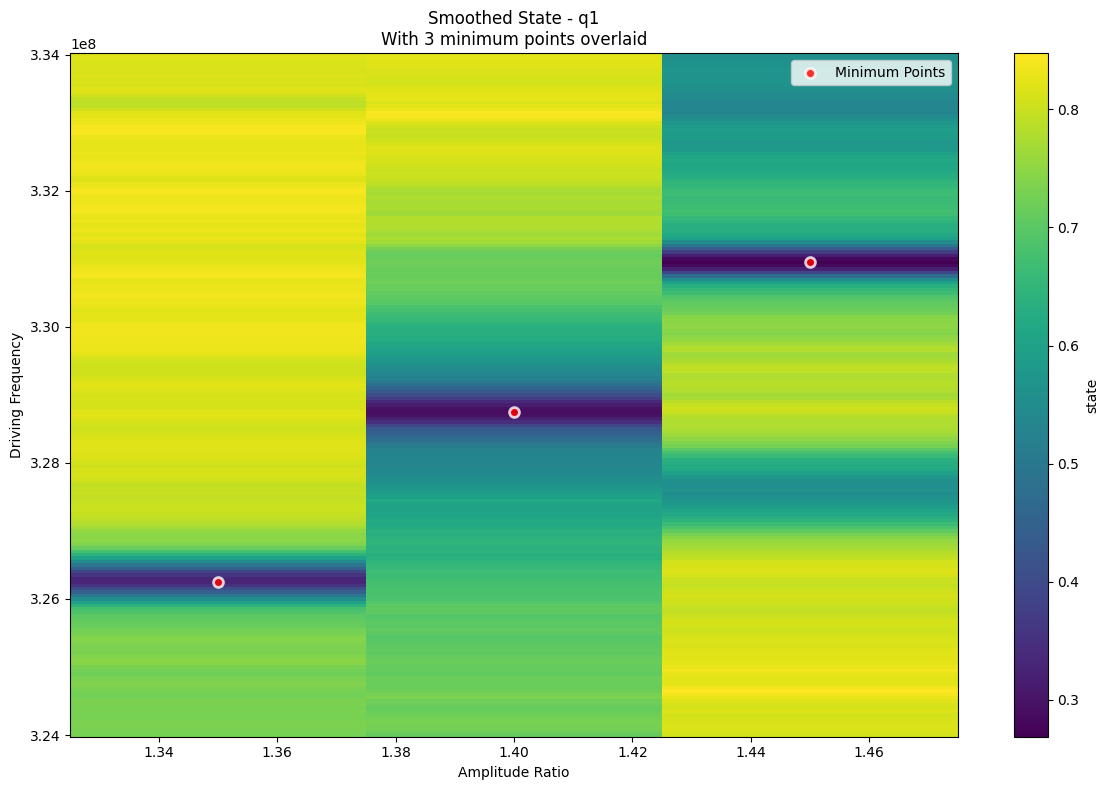


Smoothed heatmap with minimum points overlay complete!


In [42]:
# Create 2D heatmap from pre-computed smoothed data with minimum points overlaid as scatter
if ds is not None and 'qubit_data' in locals() and 'driving_points' in locals() and 'smoothed_data_dict' in locals():
    print("Creating heatmaps from pre-computed smoothed data with minimum points overlay...")
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        except:
            qubit_name = f"Dataset_{i}"
            
        print(f"\nCreating plot for {qubit_name}")
        
        # Plot parameters
        x_dim = "amplitude_ratio"
        y_dim = "driving_frequency"
        data_var = "state"
        
        # Use pre-computed smoothed data from cell 5
        if qubit_name in smoothed_data_dict:
            smoothed_data_2d = smoothed_data_dict[qubit_name]
            print(f"Using pre-computed smoothed data (shape: {smoothed_data_2d.shape})")
        else:
            print(f"Warning: No pre-computed smoothed data found for {qubit_name}, skipping...")
            continue
        
        # Get coordinate values for plotting
        x_values = sq_data.coords[x_dim].values
        y_values = sq_data.coords[y_dim].values
        
        # Create the smoothed 2D pcolormesh plot
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Create meshgrid for pcolormesh
        X, Y = np.meshgrid(x_values, y_values)
        
        # Plot smoothed data
        im = ax.pcolormesh(X, Y, smoothed_data_2d.T, shading='auto', cmap='viridis')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(data_var)
        
        # Set labels and title
        ax.set_xlabel(x_dim.replace('_', ' ').title())
        ax.set_ylabel(y_dim.replace('_', ' ').title())
        ax.set_title(f'Smoothed {data_var.title()} - {qubit_name}')
        
        # Overlay minimum points if available
        if qubit_name in driving_points:
            min_points = driving_points[qubit_name]
            amp_ratios = [point[0] for point in min_points]
            driving_freqs = [point[1] for point in min_points]
            
            # Add scatter points for minimum values
            scatter = ax.scatter(amp_ratios, driving_freqs, 
                               c='red', s=50, marker='o', 
                               edgecolors='white', linewidth=2,
                               alpha=0.8, zorder=5,
                               label='Minimum Points')
            
            # Add legend
            ax.legend(loc='upper right')
            
            # Update title to include smoothing info
            ax.set_title(f'Smoothed {data_var.title()} - {qubit_name}\nWith {len(min_points)} minimum points overlaid')
            
            print(f"Plotted smoothed data with {len(min_points)} minimum points as red circles")
        else:
            ax.set_title(f'Smoothed {data_var.title()} - {qubit_name}')
            print(f"Plotted smoothed data (no minimum points data available)")
        
        plt.tight_layout()
        plt.show()
    
    print(f"\nSmoothed heatmap with minimum points overlay complete!")
else:
    print("Required data not available. Make sure to run previous cells first.")

Creating line plots near minimum points...

Creating line plots for q1


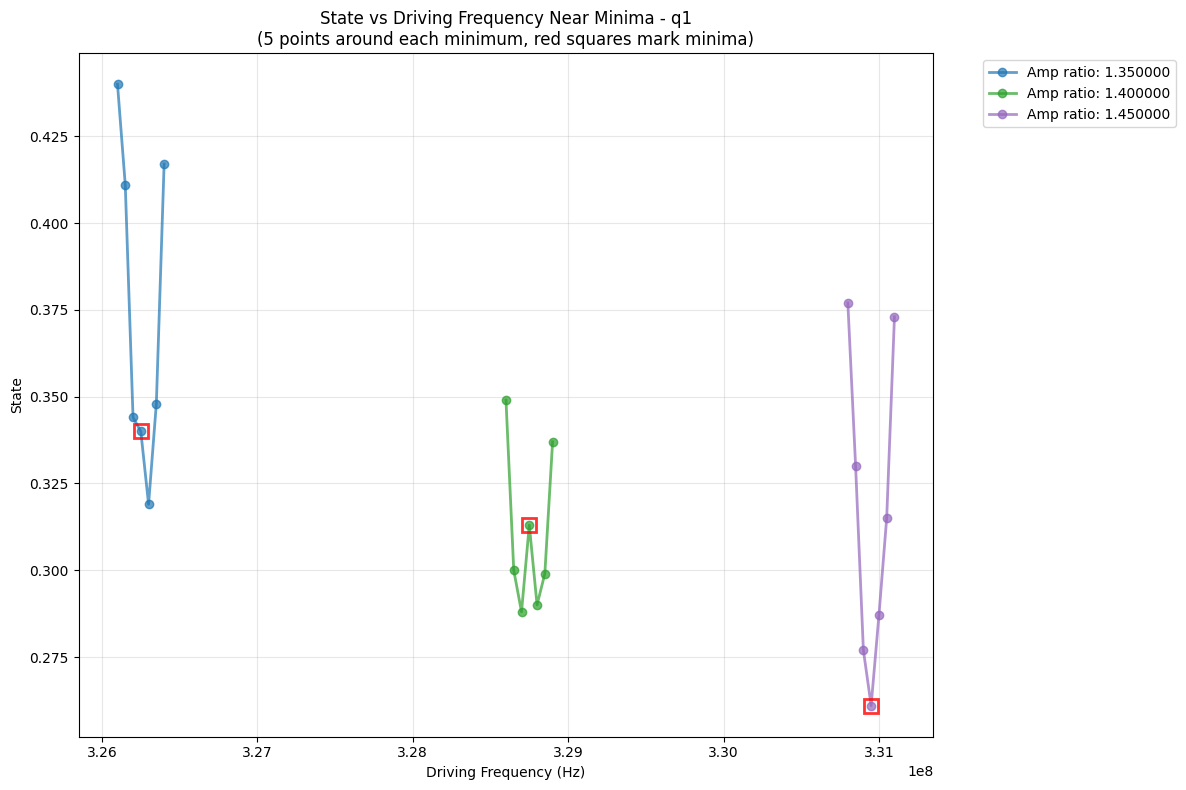

Plotted 3 lines with 5 points each around minimum frequencies

Line plots near minimum points complete!


In [43]:
# Plot state vs driving_frequency near minimum points (5 points around each minimum)
if ds is not None and 'qubit_data' in locals() and 'driving_points' in locals() and 'smoothed_data_dict' in locals():
    print("Creating line plots near minimum points...")
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        except:
            qubit_name = f"Dataset_{i}"
            
        print(f"\nCreating line plots for {qubit_name}")
        
        if qubit_name not in driving_points:
            print(f"No minimum points data available for {qubit_name}, skipping...")
            continue
            
        min_points = driving_points[qubit_name]
        driving_freq_coords = sq_data.coords['driving_frequency'].values
        
        # Create figure for line plots
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Plot lines for each amplitude ratio (sample every few to avoid cluttering)
        n_lines = min(10, len(min_points))  # Maximum 10 lines to avoid cluttering
        step = max(1, len(min_points) // n_lines)
        
        for idx in range(0, len(min_points), step):
            amp_ratio, min_freq = min_points[idx]
            
            # Find the index of the minimum frequency
            freq_idx = np.argmin(np.abs(driving_freq_coords - min_freq))
            
            # Select 5 points around the minimum (2 before, minimum, 2 after)
            start_idx = max(0, freq_idx - 3)
            end_idx = min(len(driving_freq_coords), freq_idx + 4)
            freq_indices = range(start_idx, end_idx)
            
            # Extract frequency values and corresponding state values
            freq_subset = driving_freq_coords[freq_indices]
            
            # Get state data for this amplitude ratio
            amp_data = sq_data.sel(amplitude_ratio=amp_ratio)
            state_subset = amp_data['state'].isel(driving_frequency=freq_indices).values
            
            # Plot the line
            ax.plot(freq_subset, state_subset, 'o-', 
                   label=f'Amp ratio: {amp_ratio:.6f}', 
                   linewidth=2, markersize=6, alpha=0.7)
            
            # Mark the minimum point
            min_state = amp_data['state'].sel(driving_frequency=min_freq, method='nearest').values
            ax.plot(min_freq, min_state, 's', 
                   markersize=10, markeredgecolor='red', markeredgewidth=2,
                   markerfacecolor='none', alpha=0.8)
        
        # Format the plot
        ax.set_xlabel('Driving Frequency (Hz)')
        ax.set_ylabel('State')
        ax.set_title(f'State vs Driving Frequency Near Minima - {qubit_name}\n(5 points around each minimum, red squares mark minima)')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        # Format frequency axis
        ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
        
        plt.tight_layout()
        plt.show()
        
        print(f"Plotted {min(n_lines, len(min_points))} lines with 5 points each around minimum frequencies")
    
    print("\nLine plots near minimum points complete!")
else:
    print("Required data not available. Make sure to run previous cells first.")